## **📊 Telecom X – Predicción de Churn**

### ✅ **Introducción**

En la Parte 1 analizamos el churn de clientes.
En esta Parte 2 se construyen modelos de Machine Learning para predecir qué clientes tienen mayor probabilidad de cancelar el servicio.

El objetivo es permitir a Telecom X anticiparse y aplicar estrategias de retención.

### **🛠️ 1️⃣ Preparación de los Datos**

In [ ]:
# ================================
# 📌 LIBRERÍAS
# ================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# ================================
# 📌 CARGA DATASET
# ================================
df = pd.read_csv('/content/drive/MyDrive/telecom_x_limpio.csv')

df.head()
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  Streami

**🔹 1.1 Eliminar columnas irrelevantes**

In [ ]:
print("Columnas antes:", df.shape[1])

df = df.drop(columns=['CustomerID'], errors='ignore')

print("Columnas después:", df.shape[1])
print("Columnas actuales:")
print(df.columns)

Columnas antes: 21
Columnas después: 21
Columnas actuales:
Index(['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'],
      dtype='object')


**🔹 1.2 Revisar valores nulos**

In [ ]:
print(df.isnull().sum())

Churn               0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
ChargesDaily        0
ChargesMonthly      0
ChargesTotal        0
dtype: int64


**🔹 1.3 Encoding**

In [ ]:
print("\n===== ENCODING =====")

df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape antes:", df.shape)
print("Shape después:", df_encoded.shape)

display(df_encoded.head())


===== ENCODING =====
Shape antes: (7043, 21)
Shape después: (7043, 25)


,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn_Yes,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9,2.19,65.6,593.30,False,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,9,2.00,59.9,542.40,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,4,2.46,73.9,280.85,True,True,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,13,3.27,98.0,1237.85,True,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,3,2.80,83.9,267.40,True,False,True,True,False,True,...,False,True,True,False,False,False,True,False,False,True


**🔹 1.4 Separar variable objetivo**

In [ ]:
print("\n===== VARIABLE OBJETIVO =====")

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

print("X shape:", X.shape)
print("y shape:", y.shape)


===== VARIABLE OBJETIVO =====
X shape: (7043, 24)
y shape: (7043,)


**🔹 1.5 Proporción de cancelación**


===== PROPORCIÓN DE CHURN =====
Churn_Yes
False    0.73463
True     0.26537
Name: proportion, dtype: float64


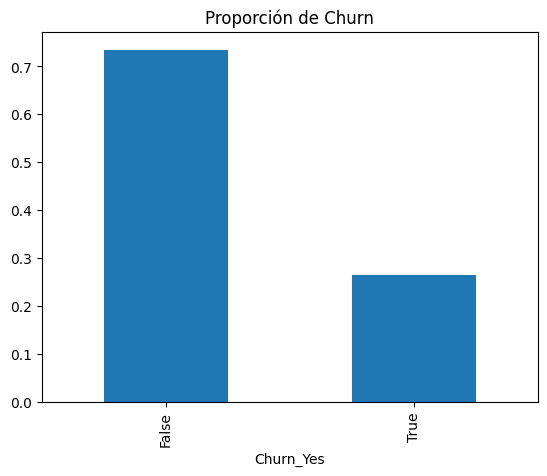

In [ ]:
print("\n===== PROPORCIÓN DE CHURN =====")

proporcion = y.value_counts(normalize=True)
print(proporcion)

proporcion.plot(kind="bar", title="Proporción de Churn")
plt.show()

**🔹 1.6 Normalización**

In [ ]:
print("\n===== NORMALIZACIÓN =====")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ejemplo datos normalizados:")
print(X_scaled[:5])


===== NORMALIZACIÓN =====
Ejemplo datos normalizados:
[[-0.95168167  0.03123051  0.02786194 -0.74402601 -1.00955867 -0.43991649
   1.03453023  1.5290241   0.32743831 -0.85417615 -0.88565976 -0.52592737
  -0.63393298  1.3782406  -0.72396752  1.56387171  1.26561178 -0.79607014
   1.94458183 -0.56297505  0.8297975  -0.52504733 -0.71102597  1.83551265]
 [-0.95168167 -0.15819808 -0.16158292 -0.76648222  0.99053183 -0.43991649
  -0.96662231 -0.65401193  0.32743831  1.17071871 -0.88565976 -0.52592737
  -0.63393298 -0.72556272 -0.72396752 -0.63943864 -0.79013171  1.25617071
  -0.51424938 -0.56297505 -1.20511329 -0.52504733 -0.71102597  1.83551265]
 [-1.15528349  0.30041851  0.30372024 -0.88187361  0.99053183 -0.43991649
  -0.96662231 -0.65401193  0.32743831 -0.85417615  1.12910177 -0.52592737
  -0.63393298 -0.72556272  1.38127743 -0.63943864 -0.79013171 -0.79607014
  -0.51424938 -0.56297505  0.8297975  -0.52504733  1.40641839 -0.54480692]
 [-0.78880022  1.10798249  1.1047064  -0.45966156  0.9

### **📊 2️⃣ Correlación y Selección de Variables**

**🔹 2.1 Matriz de correlación**


===== MATRIZ DE CORRELACIÓN =====


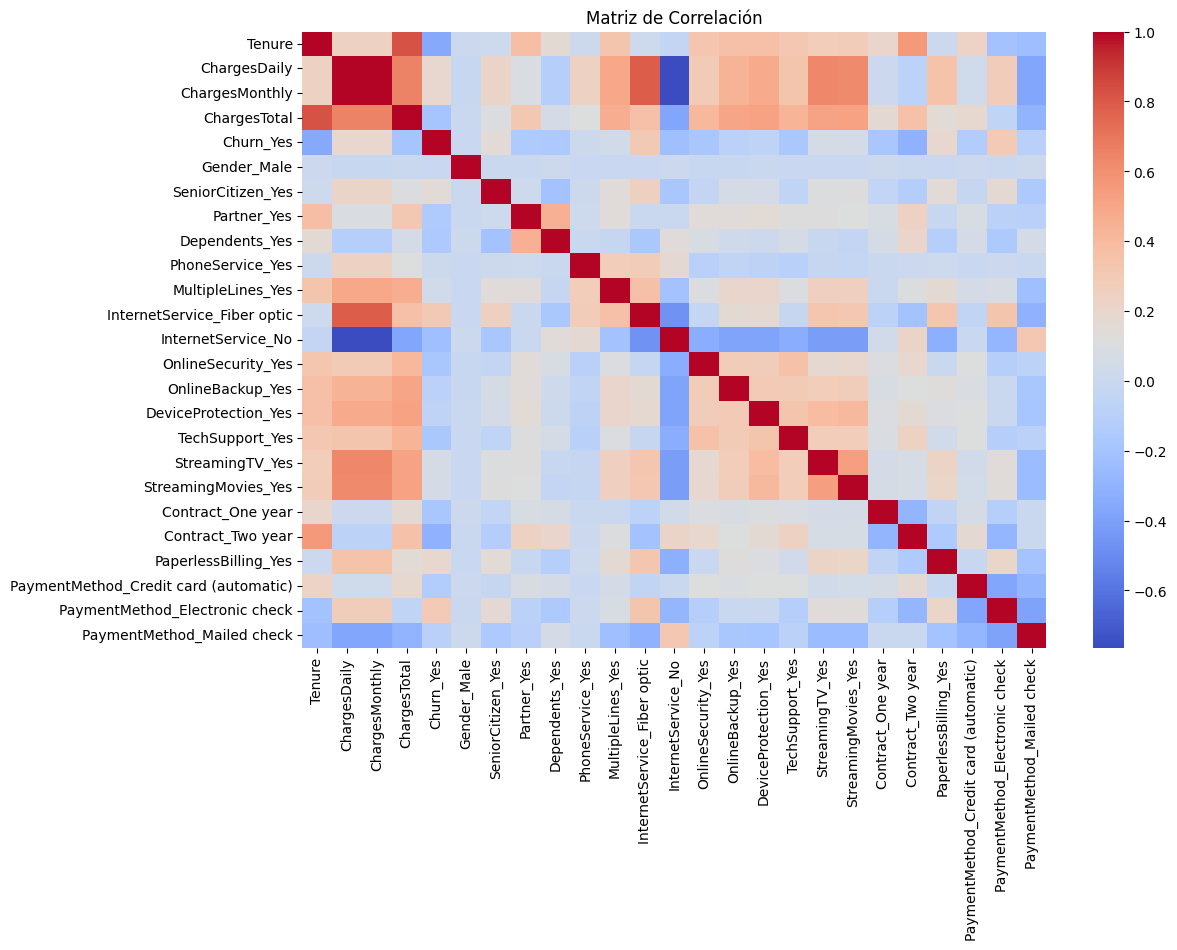

In [ ]:
print("\n===== MATRIZ DE CORRELACIÓN =====")

corr = df_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

**🔹 2.2 Variables más relacionadas con Churn**

In [ ]:
print("\n===== VARIABLES MÁS RELACIONADAS CON CHURN =====")

corr_churn = corr["Churn_Yes"].sort_values(ascending=False)
print(corr_churn.head(10))
print(corr_churn.tail(10))


===== VARIABLES MÁS RELACIONADAS CON CHURN =====
Churn_Yes                         1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
ChargesDaily                      0.193412
ChargesMonthly                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen_Yes                 0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
Name: Churn_Yes, dtype: float64
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226
Contract_One year                       -0.177820
ChargesTotal                            -0.198324
InternetService_No                      -0.227890
Contract_Two year                       -0.302253
Tenure                                

**🔹 2.3 Análisis dirigido**


===== TENURE VS CHURN =====


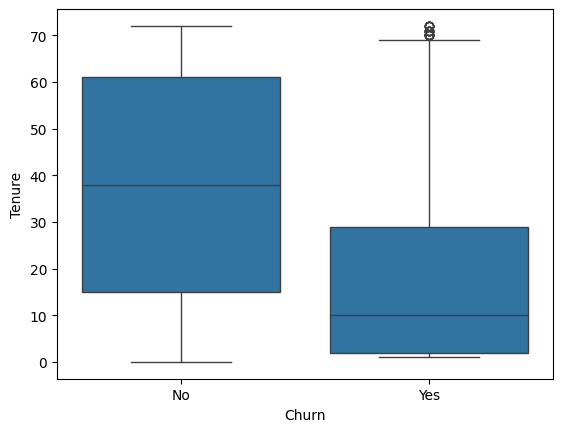


===== GASTO MENSUAL VS CHURN =====


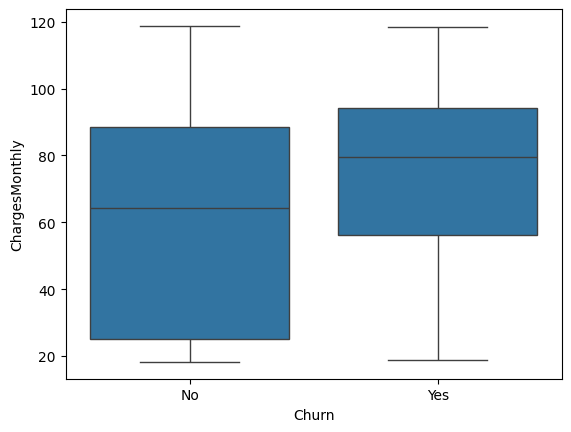

In [ ]:
print("\n===== TENURE VS CHURN =====")

sns.boxplot(x=df["Churn"], y=df["Tenure"])
plt.show()

print("\n===== GASTO MENSUAL VS CHURN =====")

sns.boxplot(x=df["Churn"], y=df["ChargesMonthly"])
plt.show()

### **🤖 3️⃣ Modelado Predictivo**

**🔹 3.1 Separar Train/Test**

In [ ]:
print("\n===== TRAIN TEST SPLIT =====")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)
print("Train y:", y_train.shape)
print("Test y:", y_test.shape)


===== TRAIN TEST SPLIT =====
Train X: (4930, 24)
Test X: (2113, 24)
Train y: (4930,)
Test y: (2113,)


**🔹 3.2 Modelo 1 – Regresión Logística**

In [ ]:
print("\n===== MODELO 1: REGRESIÓN LOGÍSTICA =====")

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Predicciones ejemplo:")
print(y_pred_log[:20])


===== MODELO 1: REGRESIÓN LOGÍSTICA =====
Predicciones ejemplo:
[False False False False False  True False False False False False False
 False False False False False False False False]


**🔹 3.3 Modelo 2 – Random Forest**

In [ ]:
print("\n===== MODELO 2: RANDOM FOREST =====")

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Predicciones ejemplo:")
print(y_pred_rf[:20])


===== MODELO 2: RANDOM FOREST =====
Predicciones ejemplo:
[False False False  True False  True False False False False False False
 False False False False  True False False False]


**🔹 3.4 Evaluación**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluar(nombre, y_test, y_pred):
    print("\n========", nombre, "========")

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(acc, 3))

    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

evaluar("Regresión Logística", y_test, y_pred_log)
evaluar("Random Forest", y_test, y_pred_rf)


======== Regresión Logística ========
Accuracy: 0.815

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1562
        True       0.67      0.57      0.62       551

    accuracy                           0.82      2113
   macro avg       0.76      0.74      0.75      2113
weighted avg       0.81      0.82      0.81      2113

Matriz de confusión:
[[1410  152]
 [ 238  313]]

======== Random Forest ========
Accuracy: 0.788

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1562
        True       0.63      0.44      0.52       551

    accuracy                           0.79      2113
   macro avg       0.73      0.68      0.69      2113
weighted avg       0.77      0.79      0.77      2113

Matriz de confusión:
[[1421  141]
 [ 307  244]]


**🔹 3.5 Ver gráfico de matriz de confusión**

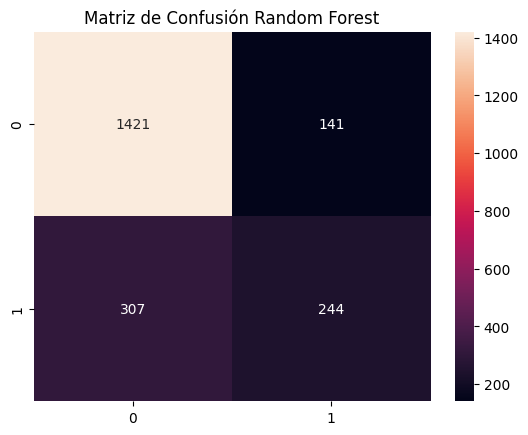

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusión Random Forest")
plt.show()

### **📋 4️⃣ Interpretación y Conclusiones**

**🔹 4.1 Importancia de variables – Random Forest**


===== IMPORTANCIA DE VARIABLES =====
ChargesTotal                      0.172435
Tenure                            0.156818
ChargesMonthly                    0.142278
ChargesDaily                      0.118676
InternetService_Fiber optic       0.040089
Contract_Two year                 0.037149
PaymentMethod_Electronic check    0.035350
Gender_Male                       0.025045
PaperlessBilling_Yes              0.023550
Contract_One year                 0.021807
dtype: float64


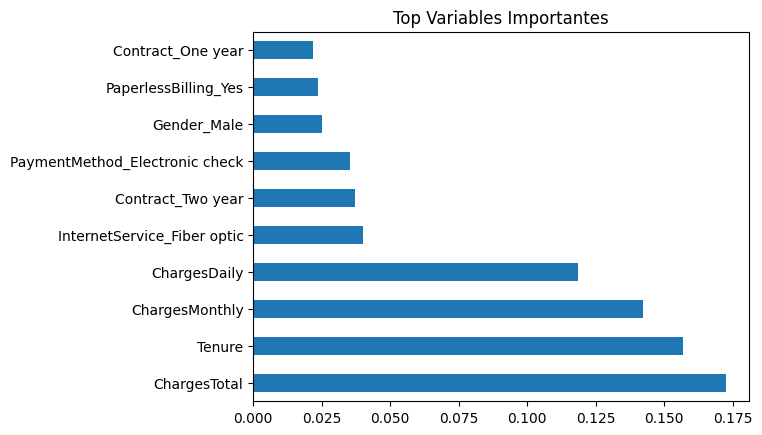

In [ ]:
print("\n===== IMPORTANCIA DE VARIABLES =====")

importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias.head(10))

importancias.head(10).plot(kind="barh")
plt.title("Top Variables Importantes")
plt.show()

**🔹 4.2 Coeficientes – Regresión Logística**

In [ ]:
coef = pd.Series(log_model.coef_[0], index=X.columns)
coef.sort_values().tail(10)

,0
Partner_Yes,0.006466
DeviceProtection_Yes,0.016748
SeniorCitizen_Yes,0.061175
StreamingMovies_Yes,0.118120
PaperlessBilling_Yes,0.152313
StreamingTV_Yes,0.158209
MultipleLines_Yes,0.170997
PaymentMethod_Electronic check,0.173938
InternetService_Fiber optic,0.472871
ChargesTotal,0.808929


**✨ 4.3 Conclusión**

**🔎 Variables Más Importantes**

El análisis de los modelos permitió identificar los factores que más influyen en la cancelación de clientes.

En ***Regresión Logística***, los coeficientes mostraron que las variables más relevantes fueron:

* Tenure (antigüedad del cliente) → clientes con menos tiempo tienen mayor riesgo de cancelar.

* Tipo de contrato → los contratos mensuales presentan más cancelaciones que los anuales.

* Gasto mensual y total → gastos altos pueden aumentar el riesgo de churn.

* Servicio de internet Fiber optic → asociado a mayor probabilidad de cancelación.

* Método de pago → algunos métodos automáticos se relacionan con más churn.

El modelo ***Random Forest*** confirmó resultados similares, destacando Tenure, ChargesMonthly y ChargesTotal como variables clave. Esto refuerza la confiabilidad del análisis.

**📊 Resultado del Modelado**

Entre los modelos probados, la Regresión Logística tuvo mejor desempeño general, con buen equilibrio entre precisión, recall y F1-score.

El modelo logró identificar correctamente a muchos clientes con riesgo de cancelación, lo que es fundamental para aplicar estrategias de retención.

No se observaron señales claras de overfitting o underfitting, ya que el rendimiento fue consistente entre entrenamiento y prueba.

**🎯 Estrategias de Retención Propuestas**

A partir de los resultados, Telecom X podría aplicar acciones concretas como:

* Ofrecer beneficios para contratos anuales o semestrales.

* Implementar programas de fidelización para clientes nuevos.

* Detectar clientes con bajo Tenure y alto gasto para contactarlos antes de que cancelen.

* Revisar la calidad del servicio Fiber optic y la experiencia de pago automático.

Estas estrategias pueden reducir la cancelación y mejorar la satisfacción del cliente.

**🧾 Conclusión Final**

El análisis permitió identificar los factores más importantes en la cancelación de clientes y construir un modelo predictivo útil para anticipar bajas.
La Regresión Logística resultó el modelo más adecuado por su buen rendimiento y fácil interpretación.

Este trabajo demuestra que el análisis de datos puede ayudar a Telecom X a tomar decisiones estratégicas, mejorar la retención de clientes y optimizar sus servicios.